In [268]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [269]:
df = pd.read_csv('titanic_data_updated.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [270]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [271]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [272]:
df.isnull().sum()
# df.drop(['Cabin'],axis=1,inplace=True)

df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [273]:
X = df.drop(['Survived'],axis=1)

X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [274]:
y = df['Survived']

y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

In [275]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [276]:
X_train
display(y_train)

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

In [277]:
X_test
display(y_test)

709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: object

In [278]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [279]:
X_test.isnull().sum()

Pclass        0
Sex           0
Age          37
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [280]:
#mean impute

age_mean = X_train['Age'].mean()

X_train['age_mean_imputor'] = X_train['Age'].fillna(age_mean)

X_test['age_mean_imputor'] = X_test['Age'].fillna(age_mean)


In [281]:
#median impute

age_median = X_train['Age'].median()


X_train['age_median_imputor'] = X_train['Age'].fillna(age_median)

X_test['age_median_imputor'] = X_test['Age'].fillna(age_median)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputor,age_median_imputor
331,first,male,45.5,0,0,28.5000,C124,S,45.500000,45.5
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000,23.0
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000,32.0
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000,26.0
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000,6.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000,21.0
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846,28.0
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000,41.0
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000,14.0


<Axes: xlabel='age_mean_imputor', ylabel='Density'>

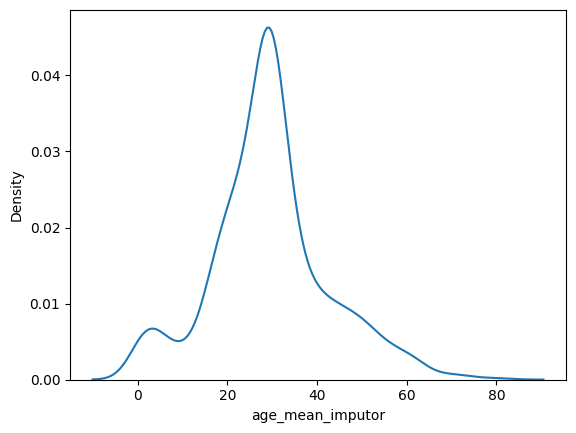

In [282]:
sns.kdeplot(data=X_train , x='age_mean_imputor')

<Axes: xlabel='age_median_imputor', ylabel='Density'>

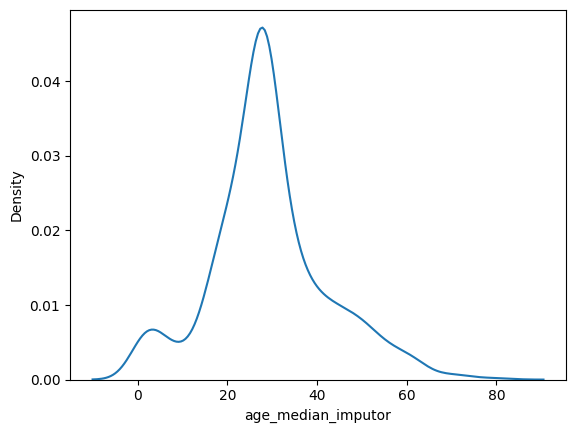

In [283]:
sns.kdeplot(data=X_train , x='age_median_imputor')

In [284]:
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(missing_values=np.nan , strategy='mean')

age_imputer.fit(X_train[['Age']])

X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()




In [285]:
X_train.isnull().sum()

X_train.drop(['age_mean_imputor','age_median_imputor'],axis=1,inplace=True)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.500000,0,0,28.5000,C124,S
733,second,male,23.000000,0,0,13.0000,NaN,S
382,third,male,32.000000,0,0,7.9250,NaN,S
704,third,male,26.000000,1,0,7.8542,NaN,S
813,third,female,6.000000,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,NaN,S
270,first,male,29.498846,0,0,31.0000,NaN,S
860,third,male,41.000000,2,0,14.1083,NaN,S
435,first,female,14.000000,1,2,120.0000,B96 B98,S


In [286]:
X_test['Age'] = age_imputer.transform(X_test[['Age']])

X_test.isnull().sum()

Pclass                  0
Sex                     0
Age                     0
SibSp                   0
Parch                   0
Fare                    0
Cabin                 134
Embarked                0
age_mean_imputor        0
age_median_imputor      0
dtype: int64

In [287]:
X_test.drop(['age_mean_imputor','age_median_imputor'],axis=1,inplace=True)

X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S
773,third,male,29.498846,0,0,7.2250,NaN,C
25,third,female,38.000000,1,5,31.3875,NaN,S
84,second,female,17.000000,0,0,10.5000,NaN,S


In [288]:
embarked_imputer = SimpleImputer(missing_values=np.nan , strategy='most_frequent')

embarked_imputer.fit(X_train[['Embarked']])

# transform both train and test data

X_train['Embarked']= embarked_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = embarked_imputer.transform(X_test[['Embarked']]).ravel()




In [289]:
X_train.isnull().sum()
X_test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

<Axes: xlabel='Cabin', ylabel='count'>

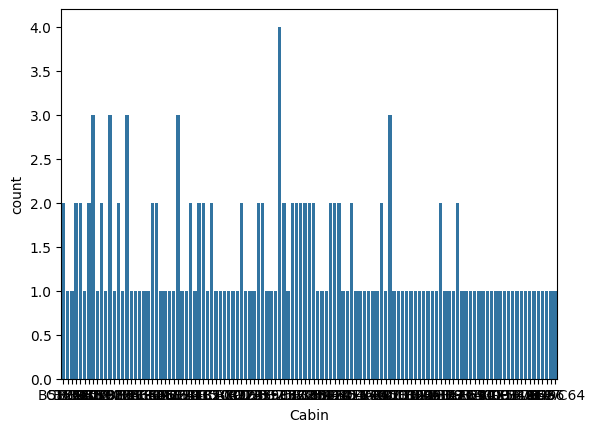

In [290]:
sns.countplot(data = X_train , x=X_train['Cabin'])

In [291]:
cabin_imputer = SimpleImputer(missing_values=np.nan , strategy='constant',fill_value='Missing',add_indicator=True)

cabin_imputer.fit(X_train[['Cabin']])

# transform both train and test data

X_train[['Cabin','cabin_missing_indicator']]= cabin_imputer.transform(X_train[['Cabin']])
X_test[['Cabin','cabin_missing_indicator']] = cabin_imputer.transform(X_test[['Cabin']])

In [292]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False


In [293]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
709,third,male,29.498846,1,1,15.2458,Missing,C,True
439,second,male,31.000000,0,0,10.5000,Missing,S,True
840,third,male,20.000000,0,0,7.9250,Missing,S,True
720,second,female,6.000000,0,1,33.0000,Missing,S,True
39,third,female,14.000000,1,0,11.2417,Missing,C,True
...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True
773,third,male,29.498846,0,0,7.2250,Missing,C,True
25,third,female,38.000000,1,5,31.3875,Missing,S,True
84,second,female,17.000000,0,0,10.5000,Missing,S,True


In [294]:
X_train.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64

In [295]:
X_test.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64

# Outlier Detection

## Using Z-Score

In [296]:
mean_of_age = X_train['Age'].mean()
std_of_age = X_train['Age'].std()

X_train['age_z_score'] = (X_train['Age'] - mean_of_age)/std_of_age
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,age_z_score
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00


In [297]:
outliers_age = X_train[abs(X_train['age_z_score'])>3]
print(len(outliers_age))
outliers_age

5


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,age_z_score
116,third,male,70.5,0,0,7.750,Missing,Q,True,3.155317
745,first,male,70.0,1,1,71.000,B22,S,False,3.116839
630,first,male,80.0,0,0,30.000,A23,S,False,3.886407
851,third,male,74.0,0,0,7.775,Missing,S,True,3.424666
672,second,male,70.0,0,0,10.500,Missing,S,True,3.116839


In [298]:
mean_of_fare = X_train['Fare'].mean()
std_of_fare = X_train['Fare'].std()
X_train['fare_z_score'] = (X_train['Fare']-mean_of_fare)/std_of_fare

outliers_fare = X_train[abs(X_train['fare_z_score'])>3]
outliers_fare

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,age_z_score,fare_z_score
118,first,male,24.000000,0,1,247.5208,B58 B60,C,False,-4.231736e-01,4.135780
716,first,female,38.000000,0,0,227.5250,C45,C,False,6.542216e-01,3.751020
377,first,male,27.000000,0,2,211.5000,C82,C,False,-1.923032e-01,3.442666
742,first,female,21.000000,2,2,262.3750,B57 B59 B63 B66,C,False,-6.540440e-01,4.421605
380,first,female,42.000000,0,0,227.5250,Missing,C,True,9.620488e-01,3.751020
779,first,female,43.000000,0,1,211.3375,B3,S,False,1.039006e+00,3.439539
730,first,female,29.000000,0,0,211.3375,B5,S,False,-3.838960e-02,3.439539
88,first,female,23.000000,3,2,263.0000,C23 C25 C27,S,False,-5.001304e-01,4.433631
341,first,female,24.000000,3,2,263.0000,C23 C25 C27,S,False,-4.231736e-01,4.433631
557,first,male,29.498846,0,0,227.5250,Missing,C,True,2.734055e-16,3.751020


# Outliers with IQR

In [299]:
# for age
age_Q1 = X_train['Age'].quantile(0.25)
age_Q3 = X_train['Age'].quantile(0.75)

age_IQR = age_Q3 - age_Q1

age_min = age_Q1 - 1.5*age_IQR
age_max = age_Q3 + 1.5*age_IQR
print(age_min)
print(age_max)

2.5
54.5


In [300]:
age_outlier = X_train[(age_min>X_train['Age']) | (X_train['Age']>age_max)]
print(len(age_outlier))

54


In [301]:
# for fare

fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)

fare_IQR = fare_Q3 - fare_Q1

fare_min = fare_Q1 - 1.5*fare_IQR
fare_max = fare_Q3 + 1.5*fare_IQR
print(fare_min)
print(fare_max)

-25.937499999999996
64.3625


In [302]:
fare_outlier = X_train[(fare_min>X_train['Fare']) | (X_train['Fare']>fare_max)]
print(len(fare_outlier))

96


# Which one is better? z or iqr



*   Normal distribution hole Z score
*   Outlier thakle IQR



In [303]:
# for age, z score is better for outlier detection (as normally distributed(almost))

# tai, jader 3 sigma er cheye choto range a ase, taderkei amra trainning data te rakhbo
X_train = X_train[abs(X_train['age_z_score'])<3]
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,age_z_score,fare_z_score
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


```python
IQR-এ “cap করে দেওয়া” বলতে বোঝায়:

👉 outlier value-গুলোকে remove না করে একটা limit-এর মধ্যে এনে দেওয়া।

মানে, খুব বড় বা খুব ছোট value থাকলে সেগুলোকে cutoff value দিয়ে replace করা হয়।

In [304]:
# for fare, IQR will be more usefull as a lot of outliers

fare_min = max(0,fare_Q1 - 1.5*fare_IQR)  # as negative fare is not possible, tai minimum fare 0 er cheye niche chole gele oita 0 kore dea hoyeche
fare_max = fare_Q3 + 1.5*fare_IQR

In [305]:
# cap kora hocche ekahne

X_train['Fare'] = X_train['Fare'].clip(fare_min, fare_max)
X_train['Fare'].max()

C:\Users\User\AppData\Local\Temp\ipykernel_1200\1164926591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Fare'] = X_train['Fare'].clip(fare_min, fare_max)


np.float64(64.3625)

In [306]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,age_z_score,fare_z_score
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,-1.192742e+00,1.682019


In [307]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
709,third,male,29.498846,1,1,15.2458,Missing,C,True
439,second,male,31.000000,0,0,10.5000,Missing,S,True
840,third,male,20.000000,0,0,7.9250,Missing,S,True
720,second,female,6.000000,0,1,33.0000,Missing,S,True
39,third,female,14.000000,1,0,11.2417,Missing,C,True
...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True
773,third,male,29.498846,0,0,7.2250,Missing,C,True
25,third,female,38.000000,1,5,31.3875,Missing,S,True
84,second,female,17.000000,0,0,10.5000,Missing,S,True


# Module 07 starting from here

## Encoder

In [308]:
X_train.drop(['age_z_score','fare_z_score'],axis=1,inplace=True)


C:\Users\User\AppData\Local\Temp\ipykernel_1200\3886638944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(['age_z_score','fare_z_score'],axis=1,inplace=True)


In [309]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False


In [310]:
from sklearn.preprocessing import OrdinalEncoder

pclass_encoder = OrdinalEncoder(categories=[['third','second','first']])
pclass_encoder.fit(X_train[['Pclass']])

X_train['Pclass_encoded'] = pclass_encoder.transform(X_train[['Pclass']]).ravel()
X_test['Pclass_encoded'] = pclass_encoder.transform(X_test[['Pclass']]).ravel()

C:\Users\User\AppData\Local\Temp\ipykernel_1200\3203257488.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Pclass_encoded'] = pclass_encoder.transform(X_train[['Pclass']]).ravel()


In [311]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Pclass_encoded
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0


In [312]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Pclass_encoded
709,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,1.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,0.0
...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,0.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,1.0


7.3 Nominal Value Encoding theory

7.4 One hot Encoding

In [313]:
from sklearn.preprocessing import OneHotEncoder

sex_encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

sex_encoder.fit(X_train[['Sex']])
encoded_df = sex_encoder.transform(X_train[['Sex']])

X_train = pd.concat([X_train,encoded_df],axis=1)
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0,0.0,1.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0,0.0,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0,0.0,1.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0,1.0,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0,0.0,1.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0,0.0,1.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0,1.0,0.0


In [314]:
from sklearn.preprocessing import OneHotEncoder

sex_encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

sex_encoder.fit(X_train[['Sex']])
encoded_df_sex = sex_encoder.transform(X_train[['Sex']])

X_train = pd.concat([X_train,encoded_df_sex],axis=1)


embarked_encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
embarked_encoder.fit(X_train[['Embarked']])
encoded_df_embarked = embarked_encoder.transform(X_train[['Embarked']])

X_train = pd.concat([X_train,encoded_df],axis=1)
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male,Sex_female,Sex_male,Sex_female,Sex_male
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0,0.0,1.0,0.0,1.0,0.0,1.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0,0.0,1.0,0.0,1.0,0.0,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0,0.0,1.0,0.0,1.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0,0.0,1.0,0.0,1.0,0.0,1.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0,1.0,0.0,1.0,0.0,1.0,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0,0.0,1.0,0.0,1.0,0.0,1.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0,0.0,1.0,0.0,1.0,0.0,1.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0,1.0,0.0,1.0,0.0,1.0,0.0


In [315]:
# transforming test data

encoded_df_sex = sex_encoder.transform(X_test[['Sex']])

X_test = pd.concat([X_test,encoded_df_sex],axis=1)


encoded_df_embarked = embarked_encoder.transform(X_test[['Embarked']])

X_test = pd.concat([X_test,encoded_df_embarked],axis=1)
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
709,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0,0.0,1.0,1.0,0.0,0.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,1.0,0.0,1.0,0.0,0.0,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,1.0,1.0,0.0,0.0,0.0,1.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,0.0,0.0,1.0,1.0,0.0,0.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0,1.0,0.0,0.0,0.0,1.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,1.0,1.0,0.0,0.0,0.0,1.0


In [316]:
X_train.drop(['Pclass','Sex','Embarked'],axis=1,inplace=True)

In [317]:
X_test.drop(['Pclass','Sex','Embarked'],axis=1,inplace=True)

7.5 Encoding the Cabin features

In [319]:
X_train['Cabin_Deck']=X_train['Cabin'].astype(str).str[0]


In [321]:
X_train['Cabin_Deck'].value_counts()

Cabin_Deck
M    550
C     52
B     37
E     24
D     19
F     12
A      9
G      3
T      1
Name: count, dtype: int64

In [ ]:
X_test['Cabin_Deck']=X_test['Cabin'].astype(str).str[0]

In [323]:
deck_ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')
deck_ohe.fit(X_train[['Cabin_Deck']])
encoded_df_deck = deck_ohe.transform(X_train[['Cabin_Deck']])
X_train = pd.concat([encoded_df_deck, X_train],axis=1)
X_train

,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T,Age,SibSp,...,Cabin,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male,Sex_female,Sex_male,Sex_female,Sex_male,Cabin_Deck
331,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,45.500000,0,...,C124,False,2.0,0.0,1.0,0.0,1.0,0.0,1.0,C
733,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,23.000000,0,...,Missing,True,1.0,0.0,1.0,0.0,1.0,0.0,1.0,M
382,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,32.000000,0,...,Missing,True,0.0,0.0,1.0,0.0,1.0,0.0,1.0,M
704,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,26.000000,1,...,Missing,True,0.0,0.0,1.0,0.0,1.0,0.0,1.0,M
813,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.000000,4,...,Missing,True,0.0,1.0,0.0,1.0,0.0,1.0,0.0,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,21.000000,0,...,Missing,True,0.0,1.0,0.0,1.0,0.0,1.0,0.0,M
270,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,29.498846,0,...,Missing,True,2.0,0.0,1.0,0.0,1.0,0.0,1.0,M
860,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,41.000000,2,...,Missing,True,0.0,0.0,1.0,0.0,1.0,0.0,1.0,M
435,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.000000,1,...,B96 B98,False,2.0,1.0,0.0,1.0,0.0,1.0,0.0,B


In [324]:
encoded_df_deck_test = deck_ohe.transform(X_test[['Cabin_Deck']])
X_test = pd.concat([encoded_df_deck_test, X_test],axis=1)
X_test

,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T,Age,SibSp,...,Fare,Cabin,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck
709,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,29.498846,1,...,15.2458,Missing,True,0.0,0.0,1.0,1.0,0.0,0.0,M
439,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,31.000000,0,...,10.5000,Missing,True,1.0,0.0,1.0,0.0,0.0,1.0,M
840,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,20.000000,0,...,7.9250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,M
720,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.000000,0,...,33.0000,Missing,True,1.0,1.0,0.0,0.0,0.0,1.0,M
39,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.000000,1,...,11.2417,Missing,True,0.0,1.0,0.0,1.0,0.0,0.0,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,17.000000,0,...,7.1250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,M
773,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,29.498846,0,...,7.2250,Missing,True,0.0,0.0,1.0,1.0,0.0,0.0,M
25,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,38.000000,1,...,31.3875,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,M
84,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,17.000000,0,...,10.5000,Missing,True,1.0,1.0,0.0,0.0,0.0,1.0,M


In [325]:
X_train.drop(columns=['Cabin_Deck'], inplace=True)
X_test.drop(columns=['Cabin_Deck'], inplace=True)

# 7.6 Label encoding -> encodes the terget column

In [327]:
y_train

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

In [329]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train)

LabelEncoder()

In [332]:
#transform
y_train_encoded_array = le.transform(y_train)
y_test_encoded_array = le.transform(y_test)


In [333]:
y_train_encoded_array

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,

In [334]:
y_train = pd.Series(y_train_encoded_array, index=y_train.index, name=y_train.name)
y_test = pd.Series(y_test_encoded_array, index=y_test.index, name=y_test.name)



In [335]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64